In [1]:
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('insurance.csv')

# Basic Info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Step 2 - Data Info & Missing Values
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB
None

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


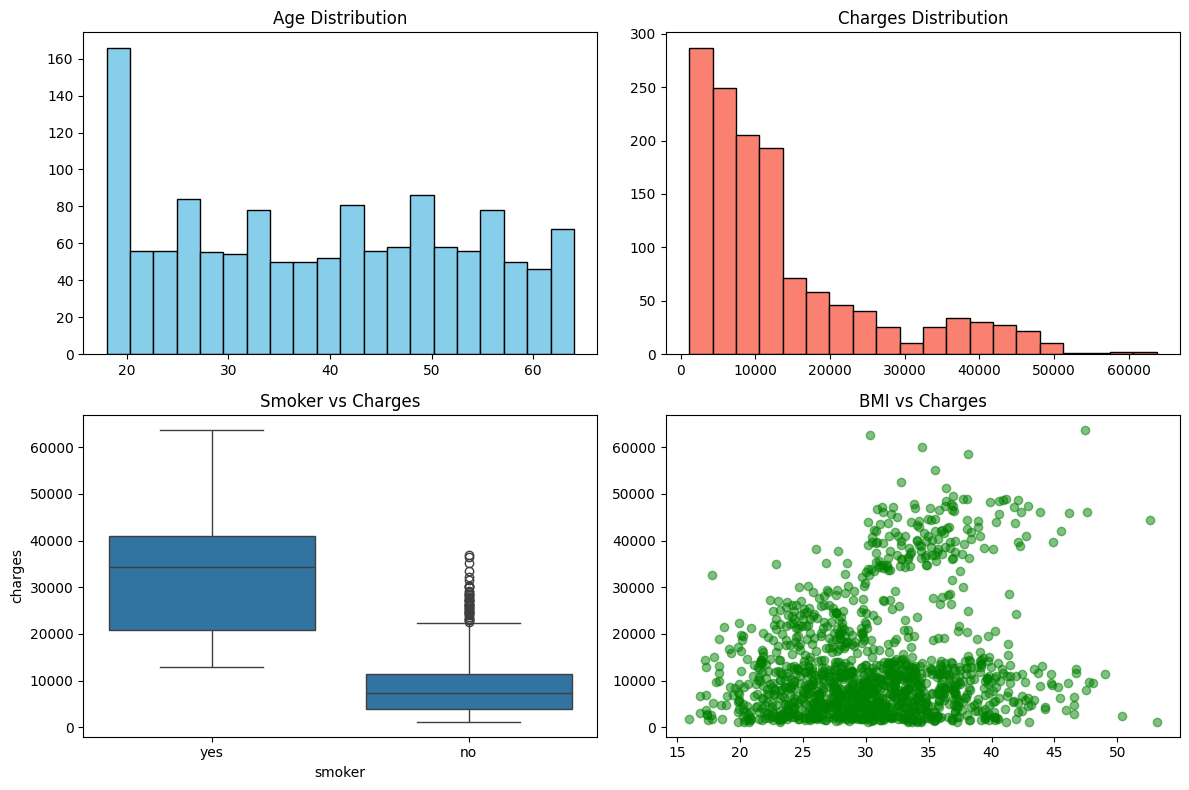

In [3]:
# Step 3 - EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Age distribution
axes[0,0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')

# Charges distribution
axes[0,1].hist(df['charges'], bins=20, color='salmon', edgecolor='black')
axes[0,1].set_title('Charges Distribution')

# Smoker vs Charges
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1,0])
axes[1,0].set_title('Smoker vs Charges')

# BMI vs Charges
axes[1,1].scatter(df['bmi'], df['charges'], alpha=0.5, color='green')
axes[1,1].set_title('BMI vs Charges')

plt.tight_layout()
plt.show()

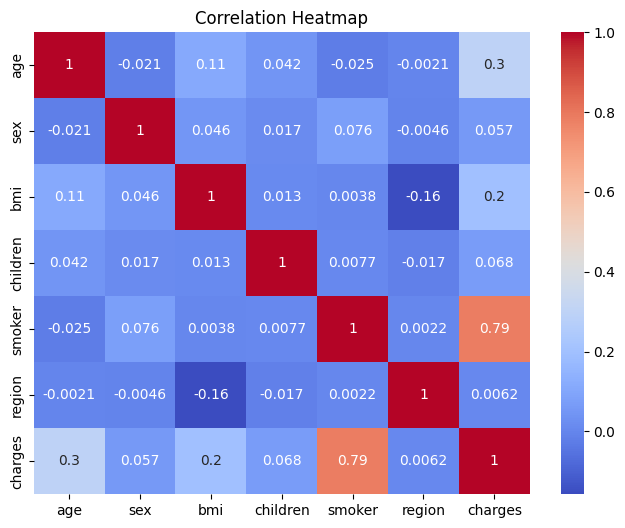

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       0  16884.92400
1   18    1  33.770         1       0       1   1725.55230
2   28    1  33.000         3       0       1   4449.46200
3   33    1  22.705         0       0       2  21984.47061
4   32    1  28.880         0       0       2   3866.85520


In [4]:
# Step 4 - Feature Engineering
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['region'] = df_encoded['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

print(df_encoded.head())

In [5]:
# Step 5 - Model Training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'R2 Score': round(r2, 4), 'MAE': round(mae, 2)}
    print(f"{name}: R2={r2:.4f}, MAE={mae:.2f}")

Linear Regression: R2=0.7833, MAE=4186.51
Random Forest: R2=0.8637, MAE=2523.09
XGBoost: R2=0.8502, MAE=2793.65


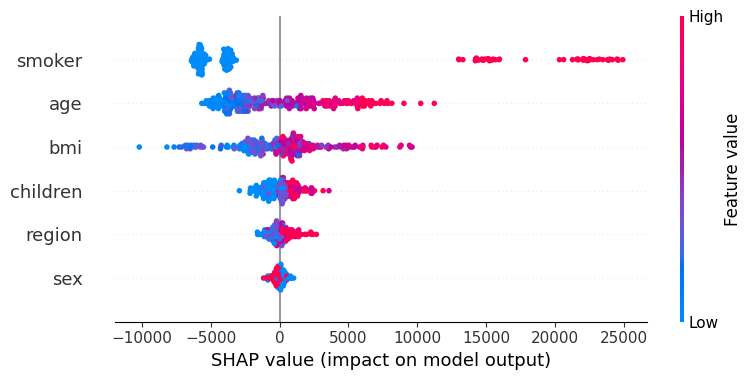

In [6]:
# Step 6 - SHAP
import shap

best_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [7]:
# Step 7 - Save Model
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved successfully! ✅")

Model saved successfully! ✅
